In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from ripser import ripser
from sklearn.metrics.pairwise import rbf_kernel

we simulate user behavior over time

each user has:
- sequence of clicks
- sequence of conversions

this captures how user interacts with ads over time

so instead of static features, we use sequences

In [8]:
def simulate_sequences(n_users=300, timesteps=20, seed=42):
    np.random.seed(seed)

    data = []

    for i in range(n_users):
        clicks = np.random.binomial(1, 0.1, timesteps)
        conversions = np.random.binomial(1, 0.05, timesteps)

        seq = np.vstack([clicks, conversions]).T
        data.append(seq)

    return data

sequences = simulate_sequences()

now we convert each sequence into point cloud

each user becomes a set of points

this allows us to apply topology

idea:
we move from time data to geometric shape

In [9]:
point_clouds = []

for seq in sequences:
    scaler = StandardScaler()
    pc = scaler.fit_transform(seq)
    point_clouds.append(pc)

now we compute persistent homology

this captures structure like:
- number of components
- loops
- complexity

we extract persistence as feature

In [10]:
features = []

for pc in point_clouds:
    dgm = ripser(pc)['dgms']
    h1 = dgm[1]

    persistence = np.sum(h1[:,1] - h1[:,0]) if len(h1) > 0 else 0
    features.append(persistence)

features = np.array(features).reshape(-1, 1)

now we build similarity between users

users with similar topology implies closer

this creates a graph structure

In [11]:
similarity = rbf_kernel(features)

now we apply spectral clustering

idea:
- use similarity graph
- find groups of similar users

this captures non-linear patterns

In [12]:
model = SpectralClustering(n_clusters=3, affinity='precomputed')
labels = model.fit_predict(similarity)

we visualize clusters

this helps us see different user groups

each cluster represents behavior type

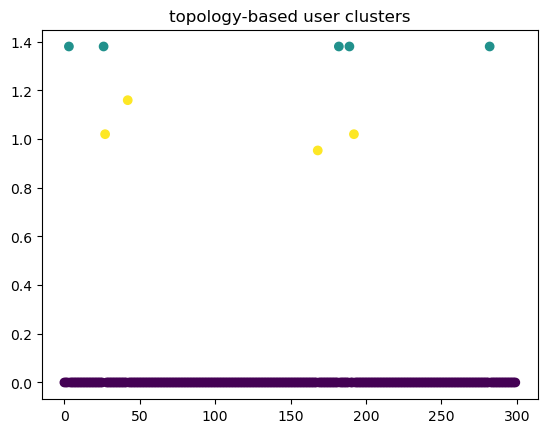

In [14]:
plt.scatter(range(len(labels)), features.flatten(), c=labels)
plt.title("topology-based user clusters")
plt.show()

## analysing the plot

most users have persistence ≈ 0  

few users have higher persistence values  

this means:

- most users behave simply (low interaction)
- few users have complex or irregular behavior

---

## clustering result

- one large cluster → simple users  
- small clusters → complex or high-activity users  

so model is separating:
- normal users  
- special users  

---

## important observation

distribution is highly skewed

means:
- majority users behave similarly  
- only few users show complex patterns  

topology helps capture these rare patterns

---

## so concluding...

topology + spectral clustering helps identify different types of users, especially rare but important high-behavior users

now we add privacy noise to sequences

we perturb:
- clicks
- conversions

this simulates privacy-preserving systems

epsilon controls noise level

In [15]:
def add_noise(seq, epsilon):
    noise = np.random.laplace(0, 1/epsilon, seq.shape)
    noisy = seq + noise
    noisy = np.clip(noisy, 0, 1)
    return noisy

epsilon = 0.5

noisy_sequences = [add_noise(seq, epsilon) for seq in sequences]

now we recompute topology after noise

this shows how data structure changes

we repeat same pipeline

In [16]:
noisy_features = []

for seq in noisy_sequences:
    scaler = StandardScaler()
    pc = scaler.fit_transform(seq)

    dgm = ripser(pc)['dgms']
    h1 = dgm[1]

    persistence = np.sum(h1[:,1] - h1[:,0]) if len(h1) > 0 else 0
    noisy_features.append(persistence)

noisy_features = np.array(noisy_features).reshape(-1, 1)

now we cluster again using noisy data

this gives new clusters

we compare with original clusters

In [17]:
similarity_noisy = rbf_kernel(noisy_features)

model = SpectralClustering(n_clusters=3, affinity='precomputed')
labels_noisy = model.fit_predict(similarity_noisy)

now we compare clusters before and after noise

we count how many users changed clusters

this measures stability

In [18]:
changes = np.sum(labels != labels_noisy)
stability = 1 - changes / len(labels)

changes, stability

(194, 0.3533333333333334)

## extension

now we added privacy noise and checked how clustering changes

we measured:
- how many users changed clusters
- how stable clustering is

---

## output

changes = 194  
stability ≈ 0.35  

---

## what this means

around 65% users changed clusters after noise

this is a very large change

means:
- clusters are not stable  
- structure is getting disturbed  

---

## interprating outputs

before noise:
clusters were based on real behavior patterns  

after noise:
noise distorts data

so:
- topology changes  
- similarity graph changes  
- clustering changes  

---

## takeaway

privacy does not just reduce accuracy

it changes:
- shape of data  
- relationships between users  
- segmentation results  

### adding noise for privacy significantly disrupts user clusters, making segmentation unstable and less reliable

so instead of just counting cluster changes, we measure how topology itself changes

we compare persistence diagrams before and after noise

this gives a distance between shapes of data

then we convert this into a stability score

higher score implies stable structure  
and vice versa

In [19]:
from persim import wasserstein

distances = []

for i in range(len(sequences)):
    seq_clean = sequences[i]
    seq_noisy = noisy_sequences[i]

    pc_clean = StandardScaler().fit_transform(seq_clean)
    pc_noisy = StandardScaler().fit_transform(seq_noisy)

    dgm_clean = ripser(pc_clean)['dgms'][1]
    dgm_noisy = ripser(pc_noisy)['dgms'][1]

    if len(dgm_clean) == 0 or len(dgm_noisy) == 0:
        dist = 0
    else:
        dist = wasserstein(dgm_clean, dgm_noisy)

    distances.append(dist)

distances = np.array(distances)

now we convert distances into stability score

we normalize distance and define:

tsi = 1 - normalized distance

so:
- tsi close to 1 implies stable
- tsi close to 0 implies unstable

In [20]:
max_dist = np.max(distances) if np.max(distances) > 0 else 1

tsi_scores = 1 - (distances / max_dist)

tsi_scores[:10], np.mean(tsi_scores)

(array([1.        , 1.        , 1.        , 0.03460705, 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ]),
 0.9798561166126762)

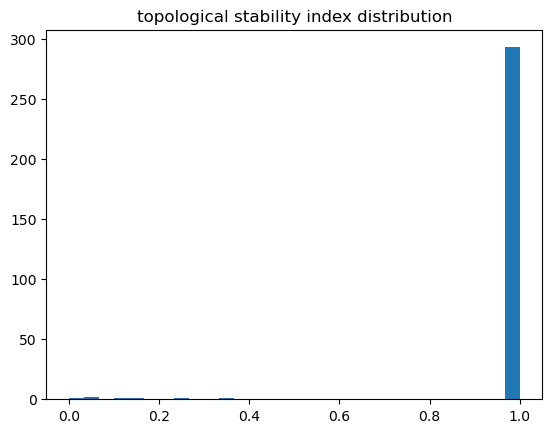

In [21]:
plt.figure()
plt.hist(tsi_scores, bins=30)
plt.title("topological stability index distribution")
plt.show()

now we connect topology with clustering

we check:
users with low tsi are like more likely to change clusters

this links:
topology to clustering stability

In [22]:
changed = (labels != labels_noisy).astype(int)

df_analysis = pd.DataFrame({
    "tsi": tsi_scores,
    "changed_cluster": changed
})

df_analysis.groupby("changed_cluster")["tsi"].mean()

changed_cluster
0    0.992852
1    0.972755
Name: tsi, dtype: float64

## overall idea

is to measure how topology changes due to privacy using tsi

tsi tells us...
how much structure of user behavior is preserved after noise

---

## analysing plot

most users have tsi very close to 1  

few users have very low tsi (near 0)

this means:

- for most users, topology is almost unchanged  
- for few users, topology is heavily distorted  

so privacy does not affect all users equally

---

## average tsi

mean tsi ≈ 0.98  

this is very high

means:

overall structure is mostly preserved  

but this can be misleading because small fraction has large distortion

---

## important observation

distribution is highly skewed

- majority users are stable  
- minority users are unstable  

these unstable users are important

because they are usually:
- high activity users  
- complex behavior users  

---

## link with clustering

cluster stability result:

users who changed clusters have lower tsi

values:

- unchanged users have tsi about 0.993  
- changed users tsi approx 0.973  

so:

lower tsi implies more likely to change cluster  

---

## interprating...

this confirms:

privacy noise first distorts topology  
then this distortion affects clustering  
which causesinstability  

---

## key insight

privacy does not uniformly degrade system

it selectively affects:

- complex users  
- structurally important users  

these are exactly the users ads systems care about

---

## takeaway

- most users remain stable under privacy  
- but important users become unstable  
- this leads to unreliable segmentation  

so measurement error is concentrated, not uniform  

---

### privacy noise preserves overall structure but distorts important user patterns, leading to instability in clustering for key users